# DeepSeek-V3 FULL model architecture pretraining on arXiv — Kaggle

This notebook keeps the complete DeepSeek-V3 **model architecture** while reducing only widths/counts so it can run on Kaggle.

Included:
- Multi-Head Latent Attention (MLA)
- decoupled RoPE / non-RoPE QK dimensions + YaRN
- DeepSeekMoE shared + routed experts
- sigmoid grouped top-k routing with correction bias
- dense early layers -> MoE later layers
- RMSNorm + SiLU gated MLP
- **sequential Multi-Token Prediction (MTP)**
  - `enorm`
  - `hnorm`
  - `eh_proj` (`2d -> d`)
  - appended full Transformer/MoE MTP layer(s)
  - shared token embedding
  - shared LM output projection
  - weighted MTP auxiliary cross-entropy objective

The released DeepSeek-V3 uses 61 main layers plus 1 MTP module; this notebook preserves that layout pattern as
`num_hidden_layers` main layers followed by `num_nextn_predict_layers` MTP layer(s).

Dataset:
`/kaggle/input/datasets/organizations/Cornell-University/arxiv/arxiv-metadata-oai-snapshot.json`

Training text:
`title + abstract`


In [1]:

# 1. INSTALL
!pip install -q "transformers==4.46.3" "tokenizers>=0.20,<0.21" sentencepiece


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 85.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.3 MB/s eta 0:00:00


In [2]:

# 2. RESTORE THE SUPPLIED ARCHITECTURE FILES
import base64, gzip
from pathlib import Path

PKG_DIR = Path("/kaggle/working/deepseek_v3_exact")
PKG_DIR.mkdir(parents=True, exist_ok=True)
(PKG_DIR / "__init__.py").write_text("", encoding="utf-8")

MODEL_BLOB = """..."""
CONFIG_BLOB = """H4sIAMS4eGoC/41XTW/jNhC961cI7iVZbA1/JG5aQIcg8bZBsWmQLvZSFANaGsmEJVIhqSTeov+9I1k2PyQX60MgzrxHDjnDN0yuZBUbxYTOpapQ6WkqRc6LRjHDpYDG8FLHvKqlMvGTQoJygdldB4ryAdvDl7IouCiiqP1AFSdHy7RAAwfjBYBgFQJcRvfr9dOf6/Xv8PS8/vJ8+/C4voe7Px4/PfwKt893vz18XcPn2yea5Z9/oyhKS6Z1fI9Ya8Td1+UhpIswxstfoph+lcywBLOvkfiTrGfB63LSuXe412Ak8EJIhcAMcJGjQpG2+L8mNdMGCASvrGxQT/6OOlqGeQwE5QbgorO0P41l/vE0epUp24Dm3zCZL35e3Mysa8uzDMXB99N8dWM9XBikA804M9hzb66WCwuoJMIQtJhdOZOIpoJ+iZLtKTvJau57Bb4bAbWiOVJzBDmYytSUJq3hDXmxNclsuvQnYMag6Apliywj7iJY/3RmowDQW0aLA77XqIy3tAAlG+P4Ftcr68W6PxVr6uE6ZSVVGOQsNVIli+m1hexeaTeKARXsLrmeO8f54jjm10tnpZcdBVIfwoeMV8nqysmtNXsbI5LwSJ7XyHoHFZqtzJKJkKx5B5NO3K0XtJk6CSkH65V/wP3xAP2lAt65pLZGupxCrvDFPaucq7aegUpDIyisS5Zi4uaWrjN0i9ZKbpIvqkHr1KlU3RE3Ik0mmheV5NlkUNaUgNZbNo6rYu9QS827ksFqg1lGM1HiV8ubq5lb/wShRH6j4CkpBVLpzZx8qUpDFyPd42SOPzoJa2hHKUu3GERdUyrogCgwniWPUjiujdTW5USBrt05PsMR3qTK3B18YqVGtxop/WaLhiXzGf2ms8DX12kQib1PG84Gk1pvRnNQvSfevB8+7N6YKvTB0gvfUZCmVodI0ezAB53JDzHOeHy6I2hEcUY+bCBcBB7YgsDG9K4Na8zuUwcySLSBbUgZ08aeOeYKwvWFsw3UtwzXC6S0XyqwBrRAP1tOYAoJvqh2BN/kE3qdJVz/5btHNZfAo3af6moxMdyhD3zxcC9nYYFOt9jAFNwHF/p6BhQK+WFWcX5WR9sJ64zCRHRi3p1/9zUyyxFhB8OiCdS/L5rAOrxJtiv0V8gafPBooyDOqD0Iz2shbWSewQe7LYWg7jCyTSEfe1LEXMetiFq5O/P2+K4bdZYWWKNR4aM6t7pHg1D2gqbWyV5gCy6Y0+fae+UMfeCp6xHq9B1e1mNL6m7ocTAC6u/tEdYPfaDfqQjqG86B+8bl4XubPdIfYlqQadSxwv4VnsWbfZzKqqZ/Sza85GZPDd1sKfsipm3EuqnrkhOse+gTMgvL8fvF/9Tn/q/vWU5D1+zicjr8P2Dw6nAHHz2Y9wJxBz7Me5DgWdjY+2TE5pP810P3goj+A0RD51IeDgAA"""

def unpack(blob):
    return gzip.decompress(base64.b64decode(blob)).decode("utf-8")

(PKG_DIR / "modeling_deepseek.py").write_text(unpack(MODEL_BLOB), encoding="utf-8")
(PKG_DIR / "configuration_deepseek.py").write_text(unpack(CONFIG_BLOB), encoding="utf-8")

print(PKG_DIR / "modeling_deepseek.py")
print(PKG_DIR / "configuration_deepseek.py")


/kaggle/working/deepseek_v3_exact/modeling_deepseek.py
/kaggle/working/deepseek_v3_exact/configuration_deepseek.py


In [3]:

# 3. IMPORT + VERIFY
import os, sys
os.environ["TOKENIZERS_PARALLELISM"] = "false"
sys.path.insert(0, "/kaggle/working")

import torch
import torch.nn.functional as F

from deepseek_v3_exact.configuration_deepseek import DeepseekV3Config
from deepseek_v3_exact.modeling_deepseek import (
    DeepseekV3RMSNorm,
    DeepseekV3YarnRotaryEmbedding,
    DeepseekV3MLP,
    MoEGate,
    DeepseekV3MoE,
    DeepseekV3Attention,
    DeepseekV3DecoderLayer,
    DeepseekV3MTPSharedHead,
    DeepseekV3MTPDecoderLayer,
    DeepseekV3Model,
    DeepseekV3ForCausalLM,
)

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

for cls in [
    DeepseekV3RMSNorm,
    DeepseekV3YarnRotaryEmbedding,
    DeepseekV3MLP,
    MoEGate,
    DeepseekV3MoE,
    DeepseekV3Attention,
    DeepseekV3DecoderLayer,
    DeepseekV3MTPSharedHead,
    DeepseekV3MTPDecoderLayer,
    DeepseekV3Model,
    DeepseekV3ForCausalLM,
]:
    print(cls.__name__)


PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
DeepseekV3RMSNorm
DeepseekV3YarnRotaryEmbedding
DeepseekV3MLP
MoEGate
DeepseekV3MoE
DeepseekV3Attention
DeepseekV3DecoderLayer
DeepseekV3MTPSharedHead
DeepseekV3MTPDecoderLayer
DeepseekV3Model
DeepseekV3ForCausalLM


In [4]:

# 4. SETTINGS
import re, gc, json, math, time, random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import IterableDataset, DataLoader
from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders
from tokenizers.processors import TemplateProcessing

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_PATH = Path("/kaggle/input/datasets/organizations/Cornell-University/arxiv/arxiv-metadata-oai-snapshot.json")
OUT_DIR = Path("/kaggle/working/arxiv_deepseek_v3")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOKENIZER_PATH = OUT_DIR / "tokenizer.json"
TOKENIZER_CONFIG_PATH = OUT_DIR / "tokenizer_config.json"
CONFIG_PATH = OUT_DIR / "config.json"
CHECKPOINT_PATH = OUT_DIR / "model.pt"
LOSS_PATH = OUT_DIR / "training_loss.png"

assert DATA_PATH.exists(), DATA_PATH

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

VOCAB_TARGET = 24000
TOKENIZER_TRAIN_DOCS = 200_000
SEQ_LEN = 512

BATCH_SIZE = 2
GRAD_ACCUM_STEPS = 8
MAX_TRAIN_STEPS = 3000
LEARNING_RATE = 3e-4
MIN_LR_RATIO = 0.10
WARMUP_STEPS = 150
WEIGHT_DECAY = 0.10
GRAD_CLIP = 1.0
LOG_EVERY = 10
SAVE_EVERY = 250

HIDDEN_SIZE = 384
INTERMEDIATE_SIZE = 1024
MOE_INTERMEDIATE_SIZE = 384

NUM_HIDDEN_LAYERS = 6
NUM_ATTENTION_HEADS = 6
NUM_KEY_VALUE_HEADS = 6

Q_LORA_RANK = 128
KV_LORA_RANK = 96
QK_NOPE_HEAD_DIM = 48
QK_ROPE_HEAD_DIM = 16
V_HEAD_DIM = 64

FIRST_K_DENSE_REPLACE = 2
N_ROUTED_EXPERTS = 8
N_SHARED_EXPERTS = 1
NUM_EXPERTS_PER_TOK = 2

N_GROUP = 4
TOPK_GROUP = 2

ROUTED_SCALING_FACTOR = 1.0
TOPK_METHOD = "noaux_tc"
SCORING_FUNC = "sigmoid"
NORM_TOPK_PROB = True

MAX_POSITION_EMBEDDINGS = 4096
ROPE_THETA = 10000.0
ROPE_SCALING = {
    "type": "yarn",
    "factor": 4.0,
    "original_max_position_embeddings": 1024,
    "beta_fast": 32,
    "beta_slow": 1,
    "mscale": 1.0,
    "mscale_all_dim": 1.0,
}

print("Device:", DEVICE)


Device: cuda


In [5]:

# 5. STREAM title + abstract
_space_re = re.compile(r"\s+")

def clean_text(x):
    if x is None:
        return ""
    return _space_re.sub(" ", str(x).replace("\x00", " ")).strip()

def iter_arxiv_documents(max_docs=None):
    count = 0
    with DATA_PATH.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue

            title = clean_text(obj.get("title"))
            abstract = clean_text(obj.get("abstract"))

            if not title and not abstract:
                continue

            text = ""
            if title:
                text += "Title: " + title
            if abstract:
                if text:
                    text += "\n"
                text += "Abstract: " + abstract

            yield text
            count += 1

            if max_docs is not None and count >= max_docs:
                return

for x in iter_arxiv_documents(max_docs=3):
    print("=" * 100)
    print(x[:1200])


Title: Calculation of prompt diphoton production cross sections at Tevatron and LHC energies
Abstract: A fully differential calculation in perturbative quantum chromodynamics is presented for the production of massive photon pairs at hadron colliders. All next-to-leading order perturbative contributions from quark-antiquark, gluon-(anti)quark, and gluon-gluon subprocesses are included, as well as all-orders resummation of initial-state gluon radiation valid at next-to-next-to-leading logarithmic accuracy. The region of phase space is specified in which the calculation is most reliable. Good agreement is demonstrated with data from the Fermilab Tevatron, and predictions are made for more detailed tests with CDF and DO data. Predictions are shown for distributions of diphoton pairs produced at the energy of the Large Hadron Collider (LHC). Distributions of the diphoton pairs from the decay of a Higgs boson are contrasted with those produced from QCD processes at the LHC, showing that enh

In [6]:

# 6. TRAIN TOKENIZER
BOS = "<｜begin▁of▁sentence｜>"
EOS = "<｜end▁of▁sentence｜>"
UNK = "<|unk|>"

if TOKENIZER_PATH.exists():
    tokenizer = Tokenizer.from_file(str(TOKENIZER_PATH))
else:
    tokenizer = Tokenizer(models.BPE(unk_token=UNK))
    tokenizer.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False)
    tokenizer.decoder = decoders.ByteLevel()

    trainer = trainers.BpeTrainer(
        vocab_size=VOCAB_TARGET,
        min_frequency=2,
        special_tokens=[BOS, EOS, UNK],
        show_progress=True,
    )

    tokenizer.train_from_iterator(
        iter_arxiv_documents(max_docs=TOKENIZER_TRAIN_DOCS),
        trainer=trainer,
        length=TOKENIZER_TRAIN_DOCS,
    )

    tokenizer.post_processor = TemplateProcessing(
        single=f"{BOS} $A {EOS}",
        special_tokens=[
            (BOS, tokenizer.token_to_id(BOS)),
            (EOS, tokenizer.token_to_id(EOS)),
        ],
    )

    tokenizer.save(str(TOKENIZER_PATH))

BOS_ID = tokenizer.token_to_id(BOS)
EOS_ID = tokenizer.token_to_id(EOS)
UNK_ID = tokenizer.token_to_id(UNK)
VOCAB_SIZE = tokenizer.get_vocab_size()

assert BOS_ID == 0
assert EOS_ID == 1

tokenizer_cfg = {
    "add_bos_token": True,
    "add_eos_token": False,
    "bos_token": BOS,
    "eos_token": EOS,
    "pad_token": EOS,
    "bos_token_id": BOS_ID,
    "eos_token_id": EOS_ID,
    "pad_token_id": EOS_ID,
    "model_max_length": MAX_POSITION_EMBEDDINGS,
}

TOKENIZER_CONFIG_PATH.write_text(
    json.dumps(tokenizer_cfg, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

print("vocab:", VOCAB_SIZE)
print("bos:", BOS_ID, "eos:", EOS_ID, "unk:", UNK_ID)





vocab: 24000
bos: 0 eos: 1 unk: 2


In [7]:

# 7. FULL DEEPSEEK CONFIG — ONLY SIZES REDUCED
config = DeepseekV3Config(
    vocab_size=VOCAB_SIZE,
    hidden_size=HIDDEN_SIZE,
    intermediate_size=INTERMEDIATE_SIZE,
    moe_intermediate_size=MOE_INTERMEDIATE_SIZE,

    num_hidden_layers=NUM_HIDDEN_LAYERS,
    num_nextn_predict_layers=1,
    mtp_loss_weight=0.3,

    num_attention_heads=NUM_ATTENTION_HEADS,
    num_key_value_heads=NUM_KEY_VALUE_HEADS,

    n_shared_experts=N_SHARED_EXPERTS,
    n_routed_experts=N_ROUTED_EXPERTS,
    ep_size=1,

    routed_scaling_factor=ROUTED_SCALING_FACTOR,

    kv_lora_rank=KV_LORA_RANK,
    q_lora_rank=Q_LORA_RANK,
    qk_rope_head_dim=QK_ROPE_HEAD_DIM,
    qk_nope_head_dim=QK_NOPE_HEAD_DIM,
    v_head_dim=V_HEAD_DIM,

    topk_method=TOPK_METHOD,
    n_group=N_GROUP,
    topk_group=TOPK_GROUP,
    num_experts_per_tok=NUM_EXPERTS_PER_TOK,

    moe_layer_freq=1,
    first_k_dense_replace=FIRST_K_DENSE_REPLACE,

    norm_topk_prob=NORM_TOPK_PROB,
    scoring_func=SCORING_FUNC,

    hidden_act="silu",
    max_position_embeddings=MAX_POSITION_EMBEDDINGS,

    initializer_range=0.006,
    rms_norm_eps=1e-6,
    use_cache=False,

    pad_token_id=EOS_ID,
    bos_token_id=BOS_ID,
    eos_token_id=EOS_ID,

    tie_word_embeddings=False,

    rope_theta=ROPE_THETA,
    rope_scaling=ROPE_SCALING,

    attention_bias=False,
    attention_dropout=0.0,
)

config._attn_implementation = "eager"

CONFIG_PATH.write_text(
    json.dumps(config.to_dict(), indent=2),
    encoding="utf-8",
)

print(config)


DeepseekV3Config {
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 0,
  "eos_token_id": 1,
  "ep_size": 1,
  "first_k_dense_replace": 2,
  "hidden_act": "silu",
  "hidden_size": 384,
  "initializer_range": 0.006,
  "intermediate_size": 1024,
  "kv_lora_rank": 96,
  "max_position_embeddings": 4096,
  "model_type": "deepseek_v3",
  "moe_intermediate_size": 384,
  "moe_layer_freq": 1,
  "mtp_loss_weight": 0.3,
  "n_group": 4,
  "n_layers": 6,
  "n_positions": 4096,
  "n_routed_experts": 8,
  "n_shared_experts": 1,
  "norm_topk_prob": true,
  "num_attention_heads": 6,
  "num_experts_per_tok": 2,
  "num_hidden_layers": 6,
  "num_key_value_heads": 6,
  "num_nextn_predict_layers": 1,
  "pad_token_id": 1,
  "q_lora_rank": 128,
  "qk_nope_head_dim": 48,
  "qk_rope_head_dim": 16,
  "rms_norm_eps": 1e-06,
  "rope_scaling": {
    "beta_fast": 32,
    "beta_slow": 1,
    "factor": 4.0,
    "mscale": 1.0,
    "mscale_all_dim": 1.0,
    "original_max_position_embeddings": 102

In [8]:
# 8. INSTANTIATE FULL DeepseekV3ForCausalLM + MTP
model = DeepseekV3ForCausalLM(config).to(DEVICE)
model.config.use_cache = False

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,} ({total_params/1e6:.2f}M)")
print(f"Trainable:        {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"Main layers:      {config.num_hidden_layers}")
print(f"MTP layers:       {config.num_nextn_predict_layers}")
print(f"Total stack:      {len(model.model.layers)}")

assert len(model.model.layers) == (
    config.num_hidden_layers + config.num_nextn_predict_layers
)

print("\nFIRST MAIN LAYER")
print(model.model.layers[0])

print("\nFIRST MoE MAIN LAYER")
print(model.model.layers[FIRST_K_DENSE_REPLACE])

mtp_layer = model.model.layers[config.num_hidden_layers]

print("\nMTP LAYER")
print(mtp_layer)

print("\nMTP STRUCTURE")
print("embed_tokens:", mtp_layer.embed_tokens)
print("enorm:", mtp_layer.enorm)
print("hnorm:", mtp_layer.hnorm)
print("eh_proj:", mtp_layer.eh_proj)
print("self_attn:", type(mtp_layer.self_attn).__name__)
print("mlp:", type(mtp_layer.mlp).__name__)
print("shared_head:", mtp_layer.shared_head)

# Physical parameter sharing used by the MTP path.
assert mtp_layer.embed_tokens.weight is model.model.embed_tokens.weight
assert mtp_layer.shared_head.head.weight is model.lm_head.weight
print("\nMTP embedding shared:", True)
print("MTP output head shared:", True)


DeepseekV3ForCausalLM has generative capabilities, as `prepare_inputs_for_generation` is explicitly overwritten. However, it doesn't directly inherit from `GenerationMixin`. From 👉v4.50👈 onwards, `PreTrainedModel` will NOT inherit from `GenerationMixin`, and this model will lose the ability to call `generate` and other related functions.
  - If you're using `trust_remote_code=True`, you can get rid of this warning by loading the model with an auto class. See https://huggingface.co/docs/transformers/en/model_doc/auto#auto-classes
  - If you are the owner of the model architecture code, please modify your model class such that it inherits from `GenerationMixin` (after `PreTrainedModel`, otherwise you'll get an exception).
  - If you are not the owner of the model architecture class, please contact the model code owner to update it.


Total parameters: 43,489,608 (43.49M)
Trainable:        43,489,608 (43.49M)
Main layers:      6
MTP layers:       1
Total stack:      7

FIRST MAIN LAYER
DeepseekV3DecoderLayer(
  (self_attn): DeepseekV3Attention(
    (q_a_proj): Linear(in_features=384, out_features=128, bias=False)
    (q_a_layernorm): DeepseekV3RMSNorm()
    (q_b_proj): Linear(in_features=128, out_features=384, bias=False)
    (kv_a_proj_with_mqa): Linear(in_features=384, out_features=112, bias=False)
    (kv_a_layernorm): DeepseekV3RMSNorm()
    (kv_b_proj): Linear(in_features=96, out_features=672, bias=False)
    (o_proj): Linear(in_features=384, out_features=384, bias=False)
    (rotary_emb): DeepseekV3YarnRotaryEmbedding()
  )
  (mlp): DeepseekV3MLP(
    (gate_proj): Linear(in_features=384, out_features=1024, bias=False)
    (up_proj): Linear(in_features=384, out_features=1024, bias=False)
    (down_proj): Linear(in_features=1024, out_features=384, bias=False)
    (act_fn): SiLU()
  )
  (input_layernorm): Deepsee

In [9]:

# 9. STREAMING DATASET
class ArxivTokenDataset(IterableDataset):
    def __init__(self, seq_len):
        super().__init__()
        self.seq_len = seq_len

    def __iter__(self):
        buffer = []

        with DATA_PATH.open("r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue

                try:
                    obj = json.loads(line)
                except json.JSONDecodeError:
                    continue

                title = clean_text(obj.get("title"))
                abstract = clean_text(obj.get("abstract"))

                if not title and not abstract:
                    continue

                text = ""
                if title:
                    text += "Title: " + title
                if abstract:
                    if text:
                        text += "\n"
                    text += "Abstract: " + abstract

                ids = tokenizer.encode(text).ids
                buffer.extend(ids)

                while len(buffer) >= self.seq_len:
                    chunk = buffer[:self.seq_len]
                    buffer = buffer[self.seq_len:]

                    x = torch.tensor(chunk, dtype=torch.long)

                    yield {
                        "input_ids": x,
                        "attention_mask": torch.ones_like(x),
                        "labels": x.clone(),
                    }

dataset = ArxivTokenDataset(SEQ_LEN)

loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

batch = next(iter(loader))
for k, v in batch.items():
    print(k, v.shape)


input_ids torch.Size([2, 512])
attention_mask torch.Size([2, 512])
labels torch.Size([2, 512])


In [10]:
# 10. FIX MIXED-PRECISION MoE + FULL FORWARD/BACKWARD SANITY TEST

def fixed_moe_forward(self, hidden_states):
    identity = hidden_states
    orig_shape = hidden_states.shape

    topk_idx, topk_weight = self.gate(hidden_states)

    hidden_states = hidden_states.view(
        -1,
        hidden_states.shape[-1]
    )

    if self.training:
        # Keep accumulator in hidden-state dtype.
        y = torch.zeros_like(hidden_states)

        for expert_id, expert in enumerate(self.experts):
            if expert is None:
                continue

            token_idx, route_idx = torch.where(
                topk_idx == expert_id
            )

            if token_idx.numel() == 0:
                continue

            expert_out = expert(
                hidden_states[token_idx]
            )

            route_weight = (
                topk_weight[token_idx, route_idx]
                .to(expert_out.dtype)
                .unsqueeze(-1)
            )

            contribution = expert_out * route_weight

            # IMPORTANT:
            # index_add_ requires source and destination
            # to have exactly the same dtype.
            contribution = contribution.to(y.dtype)

            y.index_add_(
                0,
                token_idx,
                contribution
            )

        y = y.view(*orig_shape)

    else:
        y = self.moe_infer(
            hidden_states,
            topk_idx,
            topk_weight
        ).view(*orig_shape)

    if self.config.n_shared_experts is not None:
        shared_out = self.shared_experts(identity)
        y = y + shared_out.to(y.dtype)

    return y


# Patch every DeepSeek-V3 MoE module.
for module in model.modules():
    if module.__class__.__name__ == "DeepseekV3MoE":
        module.forward = fixed_moe_forward.__get__(
            module,
            module.__class__
        )

print("patched DeepseekV3MoE mixed-precision forward")


# ============================================================
# FULL FORWARD + BACKWARD TEST — MAIN LM + MTP
# ============================================================

model.train()
model.zero_grad(set_to_none=True)

tiny = {
    k: v[:1, :64].to(DEVICE)
    for k, v in batch.items()
}

amp_dtype = (
    torch.bfloat16
    if DEVICE.type == "cuda"
    and torch.cuda.is_bf16_supported()
    else torch.float16
)

with torch.autocast(
    device_type=DEVICE.type,
    dtype=amp_dtype if DEVICE.type == "cuda" else torch.float32,
    enabled=DEVICE.type == "cuda",
):
    out = model(**tiny)

print("total loss:", float(out.loss))
print("main loss:", float(model._last_main_loss))
print("weighted MTP loss:", float(model._last_mtp_loss))

assert model._last_mtp_loss is not None
assert torch.isfinite(out.loss)

out.loss.backward()

grad_found = any(
    p.grad is not None
    and torch.isfinite(p.grad).all()
    for p in model.parameters()
)

mtp_layer = model.model.layers[
    config.num_hidden_layers
]

mtp_grad_found = (
    mtp_layer.eh_proj.weight.grad is not None
    and torch.isfinite(
        mtp_layer.eh_proj.weight.grad
    ).all()
)

print("finite model gradients:", grad_found)
print("finite MTP gradients:", bool(mtp_grad_found))

assert grad_found
assert mtp_grad_found

model.zero_grad(set_to_none=True)

print("\nFULL DeepSeek-V3 + MTP forward/backward passed")

patched DeepseekV3MoE mixed-precision forward


/tmp/ipykernel_23/3836598894.py:105: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("total loss:", float(out.loss))


total loss: 13.133403778076172
main loss: 10.100336074829102
weighted MTP loss: 3.0330679416656494
finite model gradients: True
finite MTP gradients: True

FULL DeepSeek-V3 + MTP forward/backward passed


In [11]:

# 11. OPTIMIZER
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    betas=(0.9, 0.95),
    eps=1e-8,
    weight_decay=WEIGHT_DECAY,
)

use_scaler = DEVICE.type == "cuda" and amp_dtype == torch.float16
scaler = torch.amp.GradScaler("cuda", enabled=use_scaler)

def lr_for_step(step):
    if step < WARMUP_STEPS:
        return LEARNING_RATE * (step + 1) / max(WARMUP_STEPS, 1)

    p = (step - WARMUP_STEPS) / max(MAX_TRAIN_STEPS - WARMUP_STEPS, 1)
    p = min(max(p, 0.0), 1.0)

    cosine = 0.5 * (1.0 + math.cos(math.pi * p))
    min_lr = LEARNING_RATE * MIN_LR_RATIO
    return min_lr + (LEARNING_RATE - min_lr) * cosine


In [12]:

# 12. PRETRAIN
model.train()
optimizer.zero_grad(set_to_none=True)

train_iter = iter(loader)
global_step = 0
micro_step = 0
running_loss = 0.0
steps = []
losses = []
start = time.time()

while global_step < MAX_TRAIN_STEPS:
    try:
        batch = next(train_iter)
    except StopIteration:
        train_iter = iter(loader)
        batch = next(train_iter)

    batch = {
        k: v.to(DEVICE, non_blocking=True)
        for k, v in batch.items()
    }

    with torch.autocast(
        device_type=DEVICE.type,
        dtype=amp_dtype if DEVICE.type == "cuda" else torch.float32,
        enabled=DEVICE.type == "cuda",
    ):
        out = model(**batch)
        loss = out.loss
        main_loss_value = float(model._last_main_loss) if model._last_main_loss is not None else float('nan')
        mtp_loss_value = float(model._last_mtp_loss) if model._last_mtp_loss is not None else 0.0
        backward_loss = loss / GRAD_ACCUM_STEPS

    if use_scaler:
        scaler.scale(backward_loss).backward()
    else:
        backward_loss.backward()

    running_loss += float(loss.detach())
    micro_step += 1

    if micro_step % GRAD_ACCUM_STEPS:
        continue

    if use_scaler:
        scaler.unscale_(optimizer)

    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        GRAD_CLIP,
    )

    lr = lr_for_step(global_step)
    for group in optimizer.param_groups:
        group["lr"] = lr

    if use_scaler:
        scaler.step(optimizer)
        scaler.update()
    else:
        optimizer.step()

    optimizer.zero_grad(set_to_none=True)

    global_step += 1
    mean_loss = running_loss / GRAD_ACCUM_STEPS
    running_loss = 0.0

    steps.append(global_step)
    losses.append(mean_loss)

    if global_step == 1 or global_step % LOG_EVERY == 0:
        elapsed = time.time() - start
        tokens_done = global_step * BATCH_SIZE * SEQ_LEN * GRAD_ACCUM_STEPS
        tok_s = tokens_done / max(elapsed, 1e-9)

        print(
            f"step {global_step:5d}/{MAX_TRAIN_STEPS} | "
            f"loss {mean_loss:.4f} | "
            f"ppl {math.exp(min(mean_loss, 20)):.2f} | "
            f"lr {lr:.2e} | "
            f"grad {float(grad_norm):.3f} | "
            f"~{tok_s:,.0f} tok/s"
        )

    if global_step % SAVE_EVERY == 0 or global_step == MAX_TRAIN_STEPS:
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "config": config.to_dict(),
                "step": global_step,
                "losses": losses,
            },
            CHECKPOINT_PATH,
        )
        print("saved:", CHECKPOINT_PATH)


step     1/3000 | loss 13.1164 | ppl 497015.10 | lr 2.00e-06 | grad 2.679 | ~5,041 tok/s
step    10/3000 | loss 12.9827 | ppl 434821.78 | lr 2.00e-05 | grad 2.379 | ~6,684 tok/s
step    20/3000 | loss 12.7633 | ppl 349180.39 | lr 4.00e-05 | grad 2.081 | ~6,866 tok/s
step    30/3000 | loss 12.4610 | ppl 258064.95 | lr 6.00e-05 | grad 2.332 | ~6,948 tok/s
step    40/3000 | loss 12.0765 | ppl 175697.16 | lr 8.00e-05 | grad 2.206 | ~7,008 tok/s
step    50/3000 | loss 11.5823 | ppl 107184.25 | lr 1.00e-04 | grad 2.339 | ~7,028 tok/s
step    60/3000 | loss 11.0564 | ppl 63349.86 | lr 1.20e-04 | grad 2.314 | ~7,035 tok/s
step    70/3000 | loss 10.5462 | ppl 38033.32 | lr 1.40e-04 | grad 2.286 | ~7,025 tok/s
step    80/3000 | loss 10.2554 | ppl 28436.75 | lr 1.60e-04 | grad 2.136 | ~7,002 tok/s
step    90/3000 | loss 9.7151 | ppl 16565.53 | lr 1.80e-04 | grad 2.129 | ~6,981 tok/s
step   100/3000 | loss 9.3415 | ppl 11401.49 | lr 2.00e-04 | grad 1.769 | ~6,968 tok/s
step   110/3000 | loss 9.093

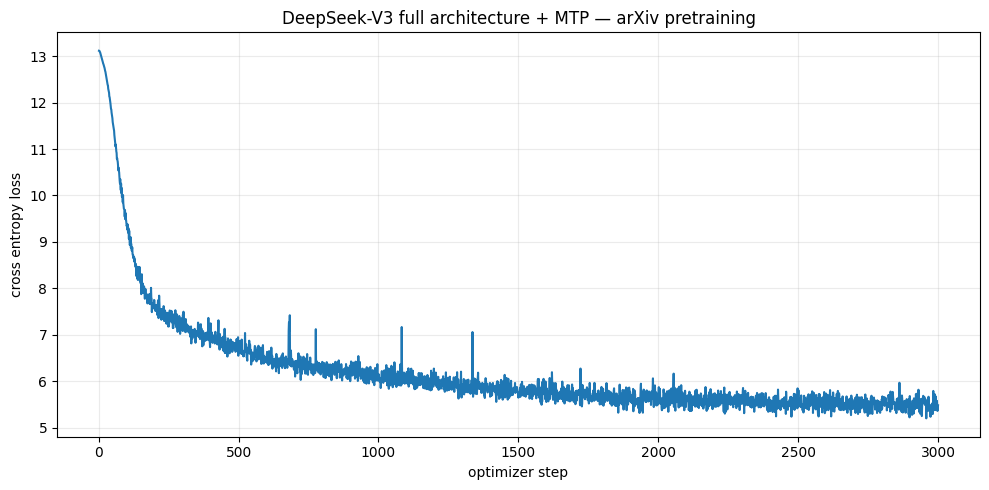

In [13]:

# 13. LOSS GRAPH
plt.figure(figsize=(10, 5))
plt.plot(steps, losses)
plt.xlabel("optimizer step")
plt.ylabel("cross entropy loss")
plt.title("DeepSeek-V3 full architecture + MTP — arXiv pretraining")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(LOSS_PATH, dpi=160)
plt.show()


In [14]:

# 14. GENERATION
@torch.no_grad()
def generate(prompt, max_new_tokens=180, temperature=0.8, top_p=0.95):
    model.eval()

    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False).ids
    ids = [BOS_ID] + prompt_ids

    for _ in range(max_new_tokens):
        context = ids[-SEQ_LEN:]

        input_ids = torch.tensor([context], dtype=torch.long, device=DEVICE)
        attention_mask = torch.ones_like(input_ids)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=amp_dtype if DEVICE.type == "cuda" else torch.float32,
            enabled=DEVICE.type == "cuda",
        ):
            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                use_cache=False,
            ).logits[0, -1].float()

        if temperature <= 0:
            next_id = int(torch.argmax(logits))
        else:
            probs = torch.softmax(logits / temperature, dim=-1)
            sorted_probs, sorted_ids = torch.sort(probs, descending=True)
            cumulative = torch.cumsum(sorted_probs, dim=-1)

            cutoff = cumulative > top_p
            cutoff[1:] = cutoff[:-1].clone()
            cutoff[0] = False

            sorted_probs[cutoff] = 0
            sorted_probs /= sorted_probs.sum()

            pick = torch.multinomial(sorted_probs, 1)
            next_id = int(sorted_ids[pick])

        ids.append(next_id)

        if next_id == EOS_ID:
            break

    model.train()
    return tokenizer.decode(ids, skip_special_tokens=True)

for prompt in [
    "Title: Quantum Entanglement\nAbstract:",
    "Title: Black Hole Thermodynamics\nAbstract:",
    "Title: Neural Networks and Scientific Discovery\nAbstract:",
]:
    print("=" * 100)
    print(generate(prompt))


Title: Quantum Entanglement
Abstract: We study the entanglement entropy of entanglement in a interacting finite-time quantum computing (LD) that are of the main body of interest in quantum information processing. We derive the eigenvalues of the entanglement measure which are expressed in terms of the probability distribution and the path integral of the entanglement. We show that the fidelity of the entanglement is derived from the state of the creation of the entanglement. The problem of this system is studied using an alternative approach in the limit of finite-time coupling which is given by the quantum limit. As a result, we obtain that the entanglement has a unique state where the effects are experimentally observed.
Title: Black Hole Thermodynamics
Abstract: We consider a simple class of light-earth black holes which are renormalized by a massive black hole. We give an explicit expression for the magnetic fields, and obtain the flow time of a black hole in the sense of the aniso

In [15]:

# 15. RELOAD CHECK
checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu")

reload_config = DeepseekV3Config(**checkpoint["config"])
reload_config._attn_implementation = "eager"
reload_config.use_cache = False

reloaded = DeepseekV3ForCausalLM(reload_config)
reloaded.load_state_dict(checkpoint["model_state_dict"])
reloaded = reloaded.to(DEVICE)

print("reloaded step:", checkpoint["step"])
print(CHECKPOINT_PATH)
print(TOKENIZER_PATH)
print(CONFIG_PATH)


reloaded step: 3000
/kaggle/working/arxiv_deepseek_v3/model.pt
/kaggle/working/arxiv_deepseek_v3/tokenizer.json
/kaggle/working/arxiv_deepseek_v3/config.json


Saved files:

- `/kaggle/working/arxiv_deepseek_v3/model.pt`
- `/kaggle/working/arxiv_deepseek_v3/config.json`
- `/kaggle/working/arxiv_deepseek_v3/tokenizer.json`
- `/kaggle/working/arxiv_deepseek_v3/tokenizer_config.json`
- `/kaggle/working/arxiv_deepseek_v3/training_loss.png`
- `/kaggle/working/deepseek_v3_exact/modeling_deepseek.py`
- `/kaggle/working/deepseek_v3_exact/configuration_deepseek.py`

The saved state dict includes the appended MTP layer(s), including `enorm`, `hnorm`, `eh_proj`,
the MTP Transformer/MoE block, and the shared embedding/output projection paths.
